In [1]:
# Python Standard Library
import sys
from os import mkdir
from os.path import join
from os.path import isdir
from shutil import rmtree

# Community Modules
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy import stats

# My Modules
sys.path.insert(0, "../code")
sys.path.insert(0, "../../ABC-SN/code")
import measure_signal as ms
import dataset_utils as du
from matplotlib import pyplot as plt
import plotly.express as px
import plotly

rng = np.random.default_rng(1415)

In [2]:
wvl, df_meta, spectra, spectra_signal, spectra_noise = du.load_dataset()

num_wvl = wvl.size
num_spectra = spectra.shape[0]

In [3]:
display(df_meta)

,SN Name,Spectrum Phase,Spectrum Cardinality,SN Subtype,SN Maintype,SN Subtype ID,SN Maintype ID,SNR,S (SNR),N (SNR),Denoising Parameter,searchBlu,searchRed,minima_i,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed,useBlu,useRed
0,sn1981b,-1.5,1,Ia-norm,Ia,0,0,1871.524905,10.201020,0.005451,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
1,sn1981b,15.4,1,Ia-norm,Ia,0,0,2098.887305,6.663471,0.003175,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
2,sn1981b,18.3,1,Ia-norm,Ia,0,0,2239.138885,7.397255,0.003304,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
3,sn1981b,22.3,1,Ia-norm,Ia,0,0,556.796633,3.159352,0.005674,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
4,sn1989b,-7.2,1,Ia-norm,Ia,0,0,1568.676779,8.039676,0.005125,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3569,sn2006bp,17.2,1,IIP,II,9,3,1909.429755,7.142203,0.003740,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
3570,sn2006bp,20.1,1,IIP,II,9,3,639.508576,7.011980,0.010965,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
3571,sn2006bp,25.2,1,IIP,II,9,3,2430.950291,10.546622,0.004338,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True
3572,sn2006bp,34.1,1,IIP,II,9,3,3897.900603,15.915556,0.004083,10.0,500.0,0.0,NaN,0.0,0.0,100.0,100.0,True,True


<Axes: >

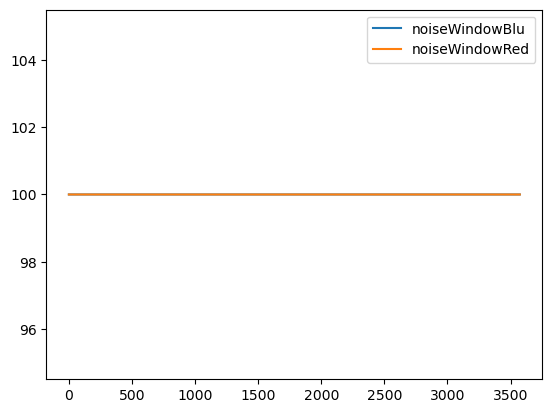

In [93]:

df_meta[["noiseWindowBlu","noiseWindowRed"]].plot()

In [5]:
num_wvl

1024

In [6]:
spectra_signal

array([[0.64921766, 0.64921766, 0.64921766, ..., 0.64921766, 0.64921766,
        0.64921766],
       [0.39144612, 0.39144612, 0.39144612, ..., 0.39144612, 0.39144612,
        0.39144612],
       [0.36242323, 0.36242323, 0.36242323, ..., 0.36242323, 0.36242323,
        0.36242323],
       ...,
       [0.42702213, 0.42702213, 0.42702213, ..., 0.42702213, 0.42702213,
        0.42702213],
       [0.41418552, 0.41418552, 0.41418552, ..., 0.41418552, 0.41418552,
        0.41418552],
       [0.38299742, 0.38299742, 0.38299742, ..., 0.38299742, 0.38299742,
        0.38299742]])

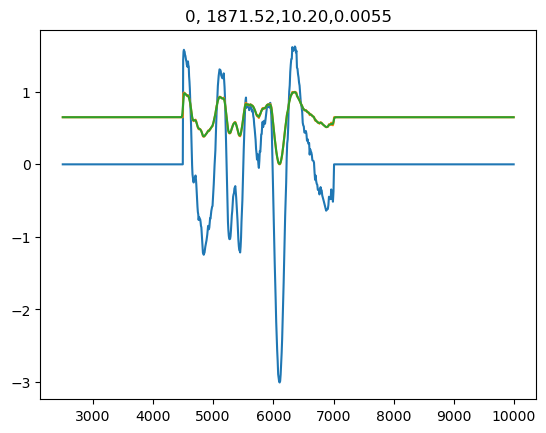

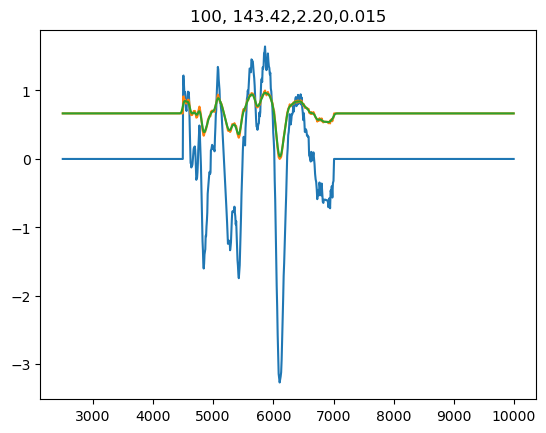

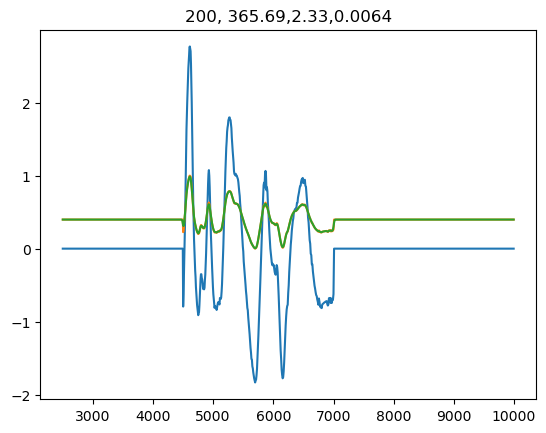

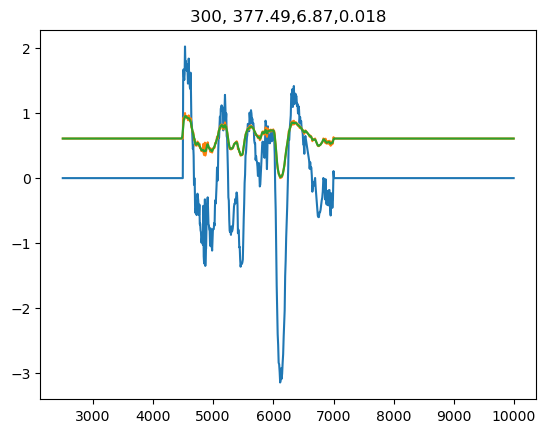

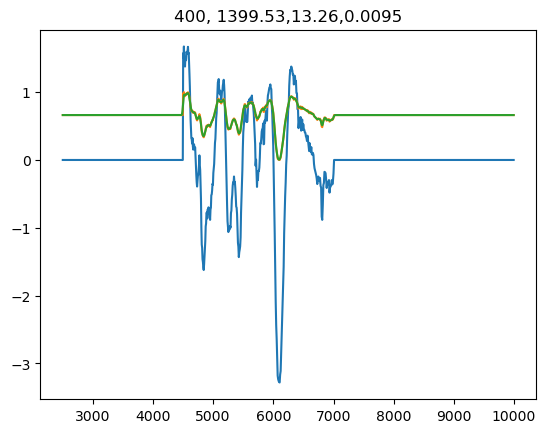

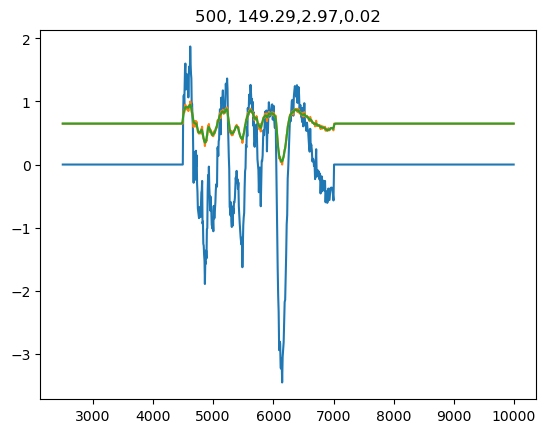

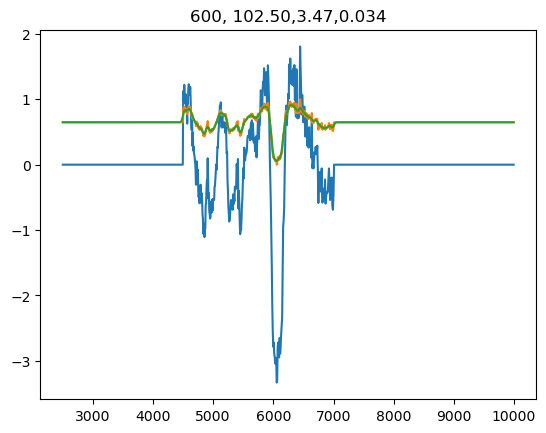

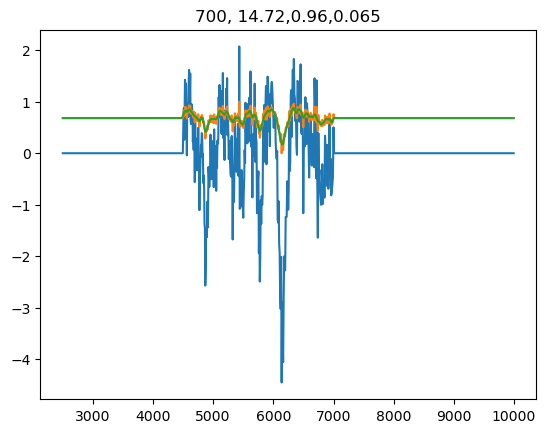

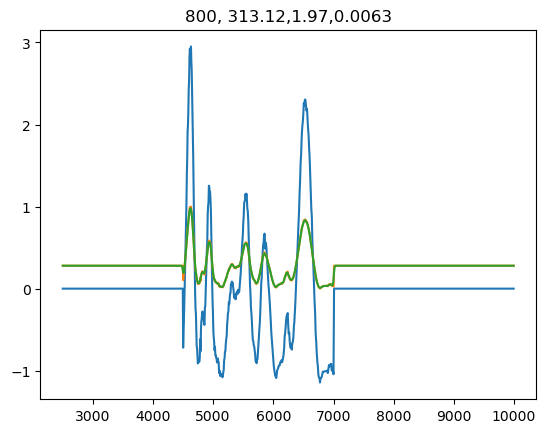

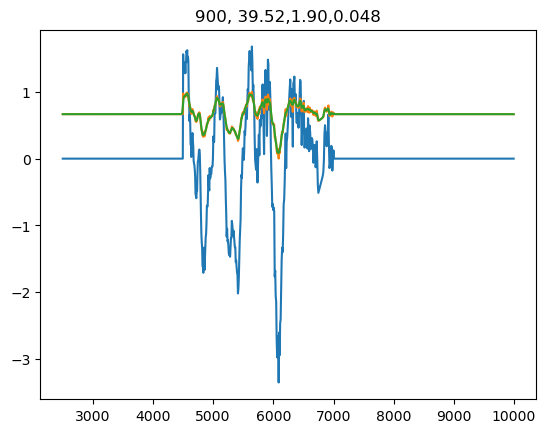

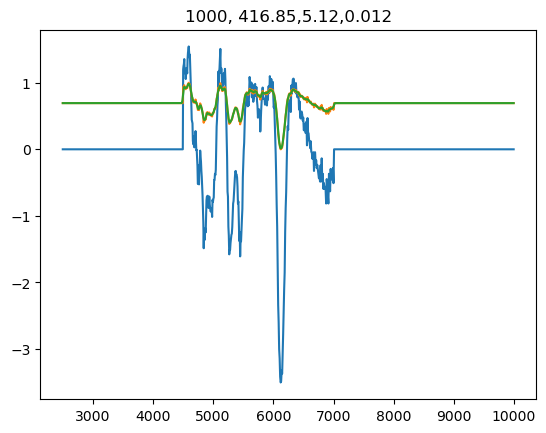

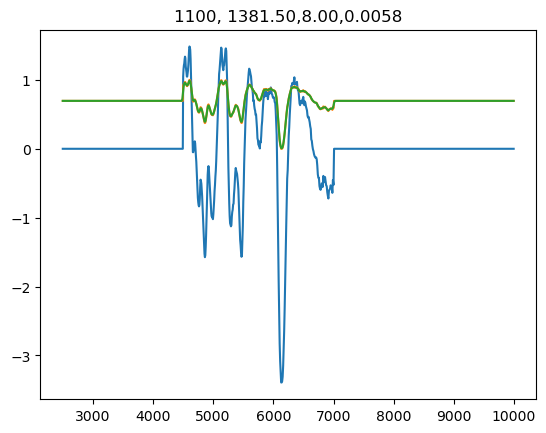

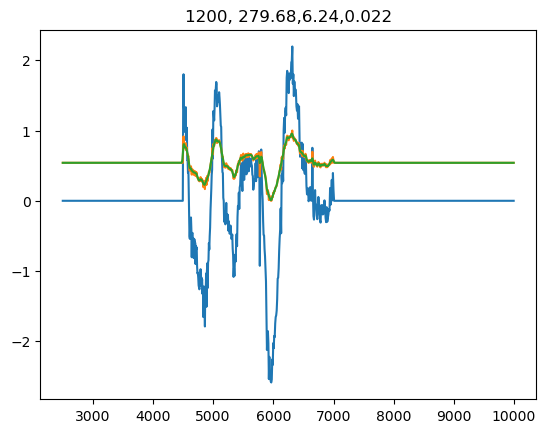

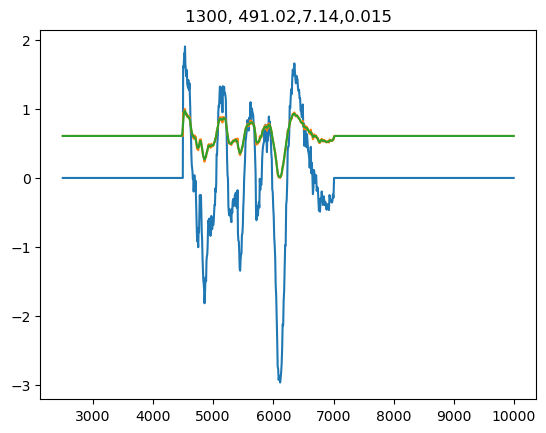

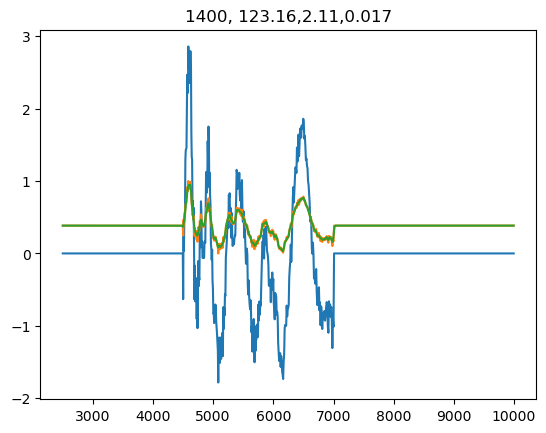

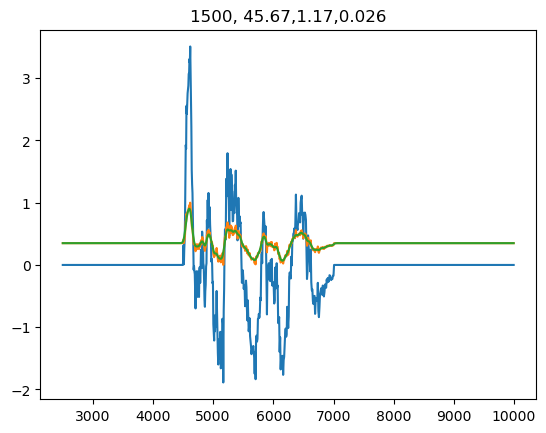

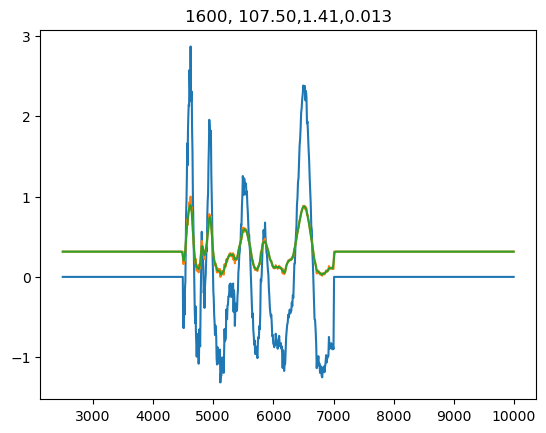

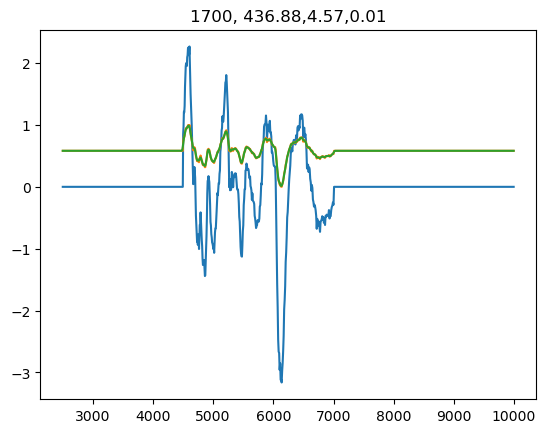

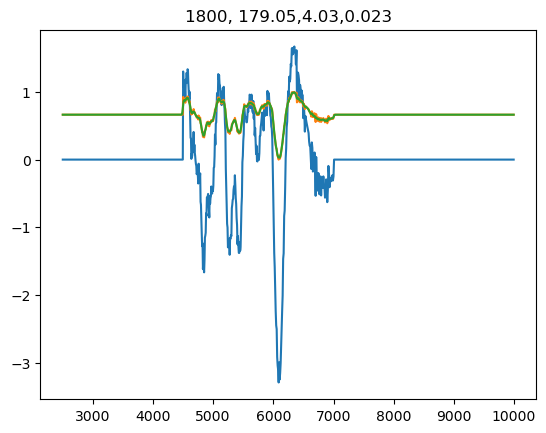

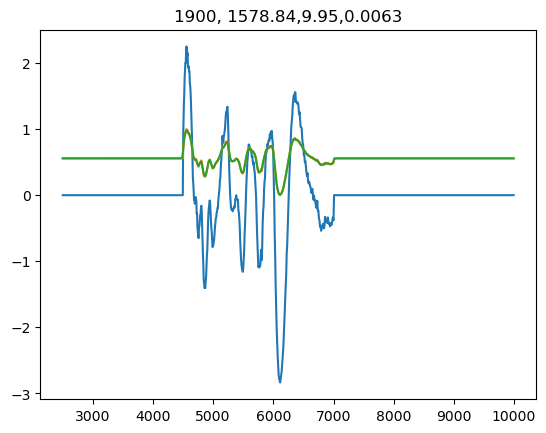

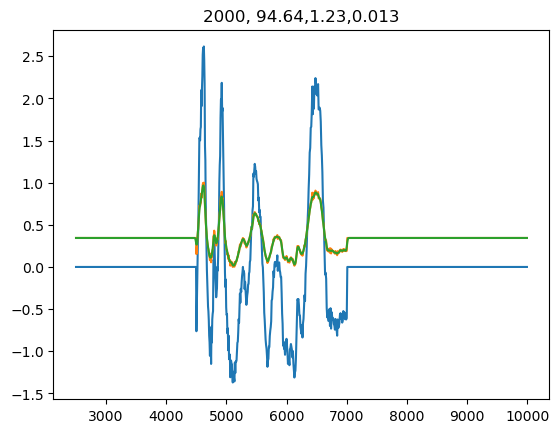

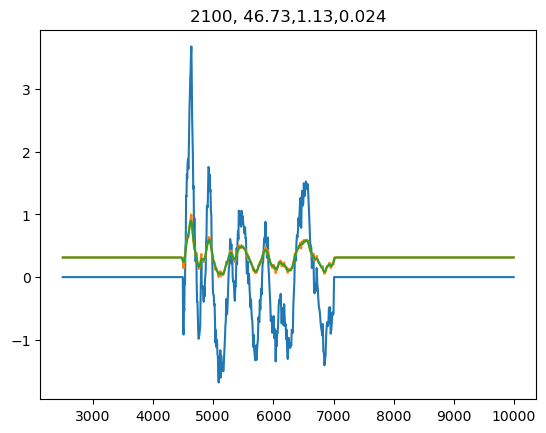

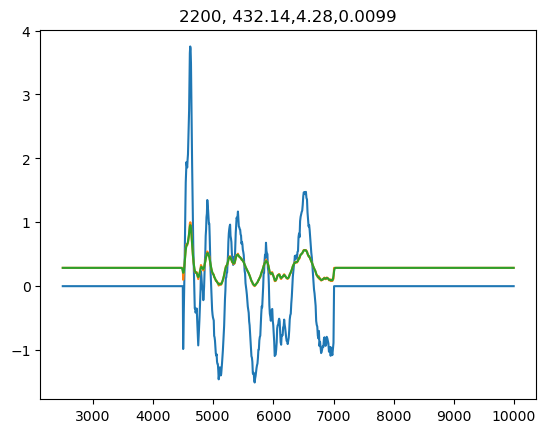

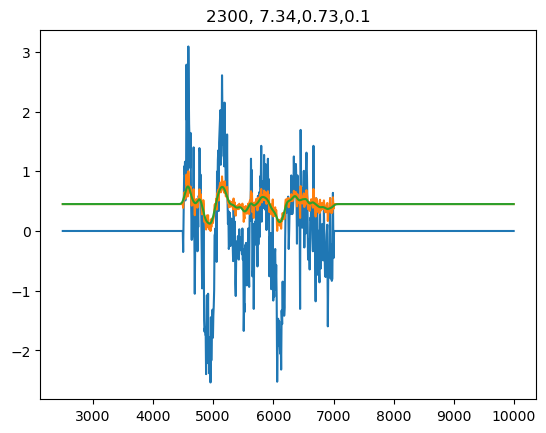

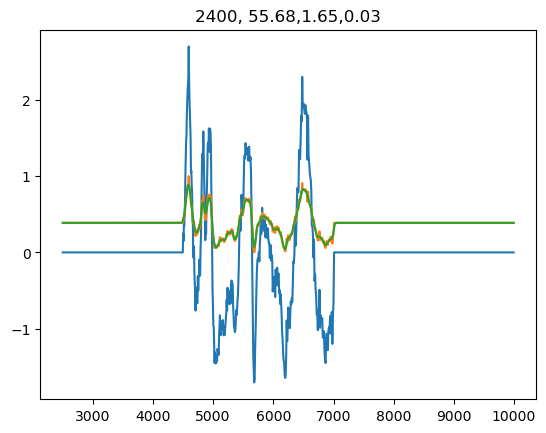

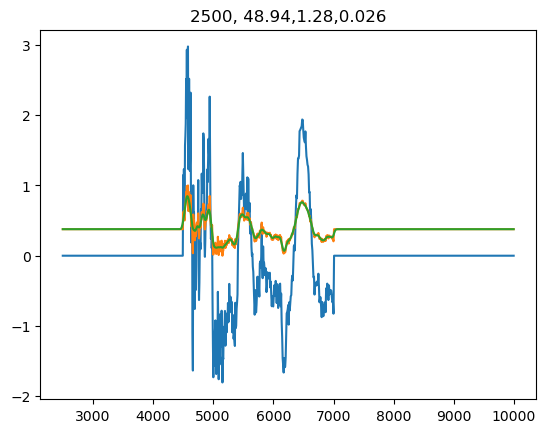

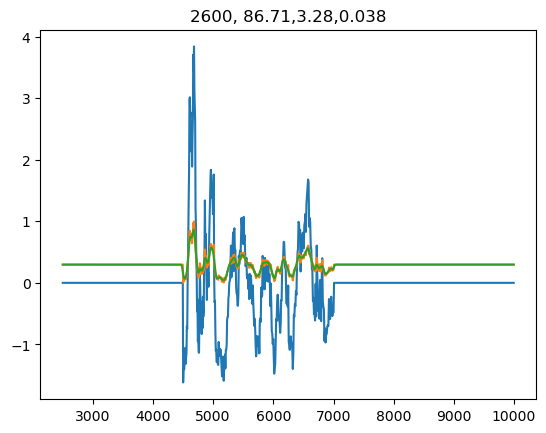

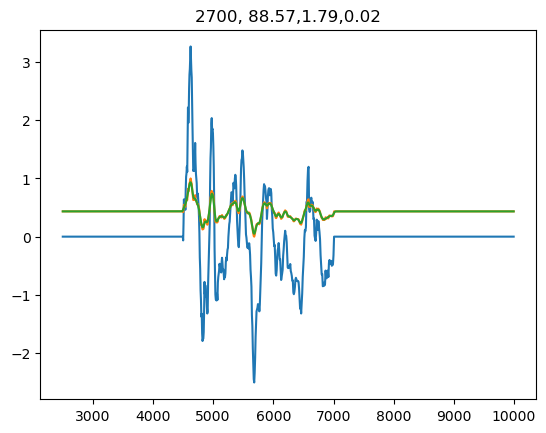

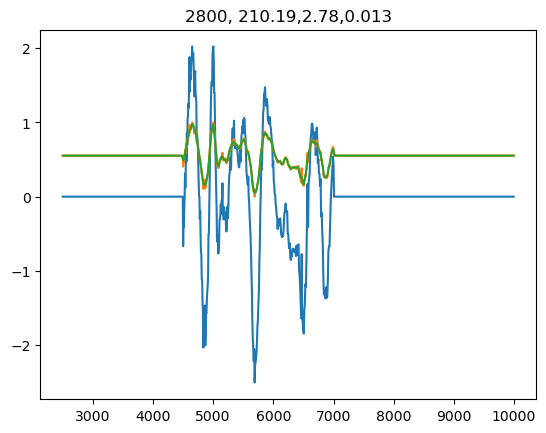

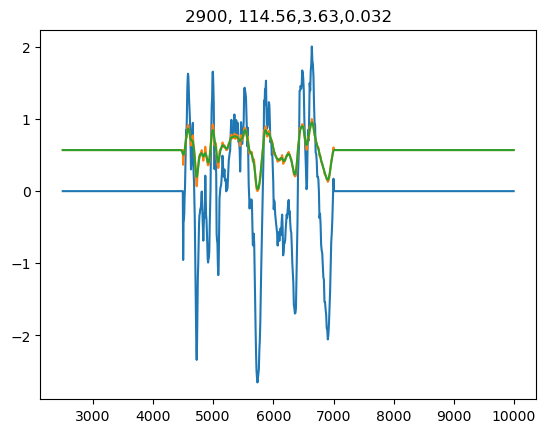

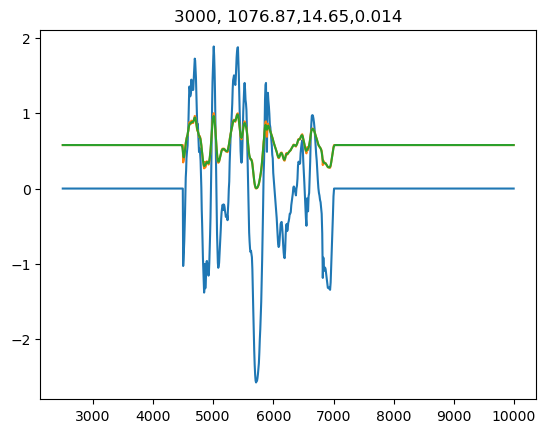

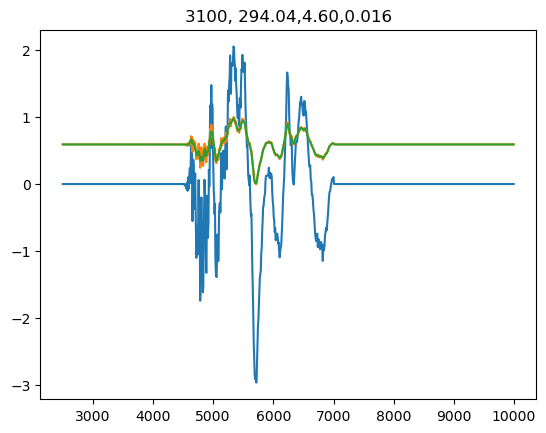

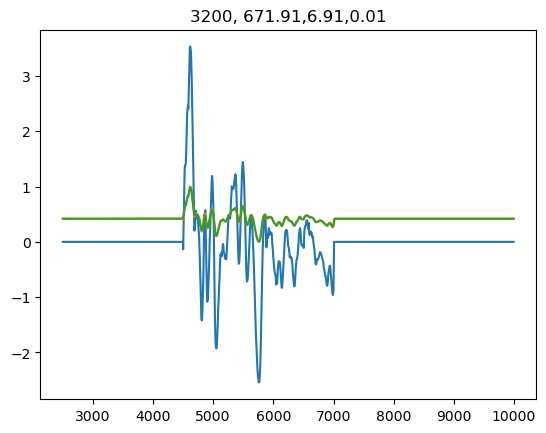

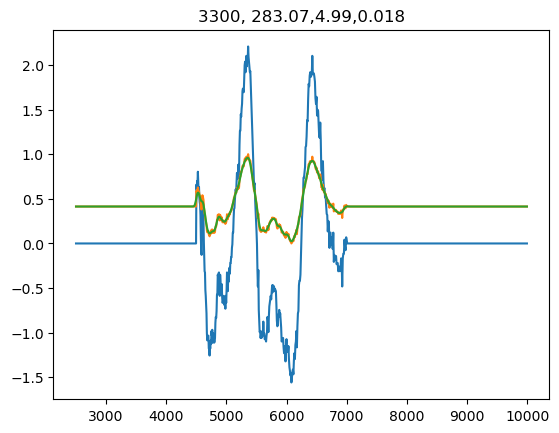

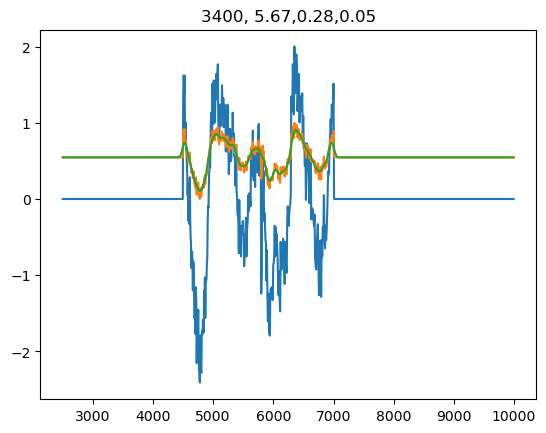

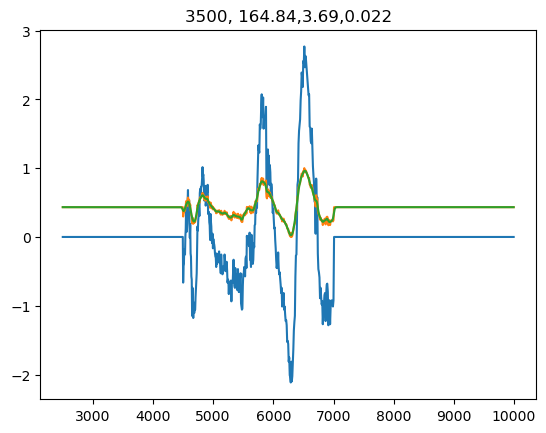

In [7]:
for i in range(0, num_spectra, 100):
    plt.plot(wvl, spectra[i])
    
    plt.plot(wvl, spectra_signal[i] + spectra_noise[i] )
    plt.plot(wvl, spectra_signal[i])
    plt.title(f'{i}, {df_meta.iloc[i]["SNR"]:.2f},{df_meta.iloc[i]["S (SNR)"]:.2f},{df_meta.iloc[i]["N (SNR)"]:.2g}')
    
    #display(df_meta)
    plt.show()

In [8]:
new_SNR = 100
new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
new_spectra = spectra_signal + new_noise

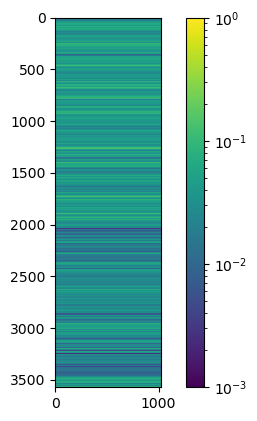

In [9]:
from matplotlib.colors import LogNorm
plt.imshow(new_N_arr, norm=LogNorm(vmin=1e-3, vmax=1))
plt.colorbar()

0.10456203930080332 0.006120521183677503 0.10201019836742894
0.06916748651631802 0.00012255893579263217 0.06663470582482157
0.07184320378779994 0.002672571551831305 0.0739725458061122
0.03153700944610172 0.0006449206461918474 0.03159351554874606
0.08022609013682813 -0.0011422818305252382 0.08039675608164855
0.07514028754900641 0.003315046246159443 0.08039675608164865
0.07833866069934013 0.0002464455919096515 0.07595829946489957
0.07582744681576926 0.000869677540274349 0.07590216557035964
0.025502872700900184 -0.0011126042601327436 0.0254728654112962
0.02154528155249214 0.001119756323206899 0.020971605075689598


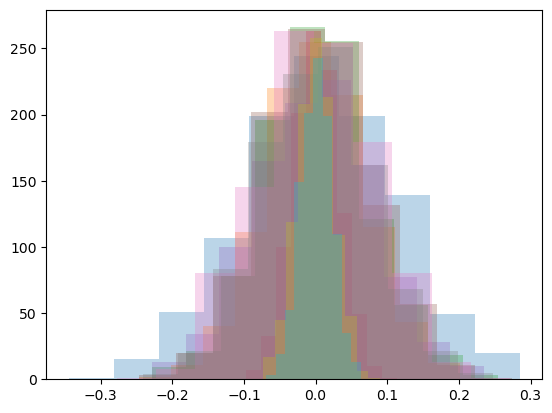

In [10]:
for i in range(10):
    plt.hist(new_noise[i], alpha=0.3)
    print(new_noise[i].std(), new_noise[i].mean(), new_N_arr[i,0])

In [11]:
new_noise.max()

1.1295244241024247

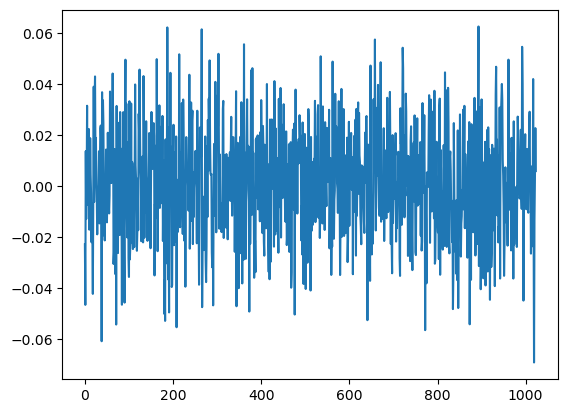

In [12]:
plt.plot(new_noise[i])

In [13]:
subtypes_ID = df_meta["SN Subtype ID"].unique()
subtypes_ID_to_str = dict(
    df_meta.groupby(by="SN Subtype ID")["SN Subtype"].apply(
        lambda x: x.to_numpy()[0]))

In [94]:
snrs = []
for snr in tqdm(range(1,100)):
    for j in range(1):
        for i in range(10):#tqdm(range(num_spectra)):
        
            i_row_series = df_meta.loc[i]
            i_spectra = spectra[i]
            i_spectra_signal = spectra_signal[i]
            i_spectra_noise = spectra_noise[i]
            new_noise = i_row_series["S (SNR)"] / snr #signal / (signal / noise)
            #print(new_noise)
            i_new_noise = stats.norm.rvs(loc=0, scale=new_noise, size=num_wvl, random_state=rng)
            #print(new_noise, i_new_noise.std())
    
            i_row_series["noiseWindowBlu"]= 200
            i_row_series["noiseWindowRed"]= 200
            
            #i_specsnr = ms.SpectrumSNR(
            #     i_row_series["SN Name"],
            #     i_row_series["SN Subtype"],
            #     i_row_series["Spectrum Phase"],
            #     wvl,
            #     i_spectra)
            #i_specsnr.execute_algorithm(i_row_series)
        
            i_specsnr_new_noise = ms.SpectrumSNR(
                i_row_series["SN Name"],
                i_row_series["SN Subtype"], 
                i_row_series["Spectrum Phase"],
                wvl,
                i_spectra)
            
            i_specsnr_new_noise.execute_algorithm(i_row_series, new_noise=i_new_noise)
            
            df_meta.loc[i, "new_measured_SNR"] = i_specsnr_new_noise.SNR
            df_meta.loc[i, "new_measured_N"] = i_specsnr_new_noise.N
            snrs.append(np.array(([snr, new_noise, i_specsnr_new_noise.N, i_specsnr_new_noise.SNR])))
snrs = np.array(snrs)
snrs.shape

  0%|                                                                                         | 0/99 [00:00<?, ?it/s]/var/folders/55/hm2934r523sg5qfprlq_4zkm0000gq/T/ipykernel_33046/2121984726.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/55/hm2934r523sg5qfprlq_4zkm0000gq/T/ipykernel_33046/2121984726.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

100%|████████████████████████████████████████████████████████████████████████████████| 99/99 [00:25<00:00,  3.90it/s]


(990, 4)

Text(0, 0.5, 'measured noise')

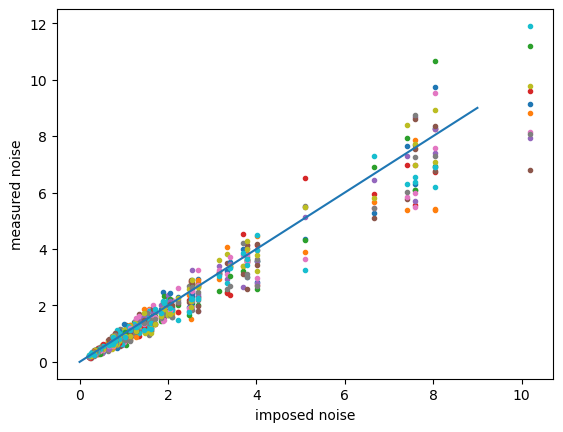

In [85]:
for j in range(0,100):
    #plt.plot(snrs[:,1], snrs[:,2], '.')
    plt.plot(snrs[j*10:j*10+10,1], snrs[j*10:j*10+10,2], '.')
plt.plot(range(10), range(10))
plt.xlabel("imposed noise")
plt.ylabel("measured noise")

Text(0, 0.5, 'measured noise')

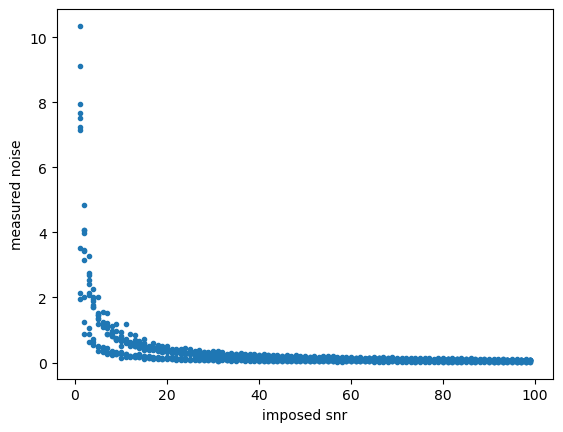

In [98]:
plt.plot(snrs[:,0], snrs[:,2], '.')
plt.xlabel("imposed snr")
plt.ylabel("measured noise")

Text(0, 0.5, 'measured noise')

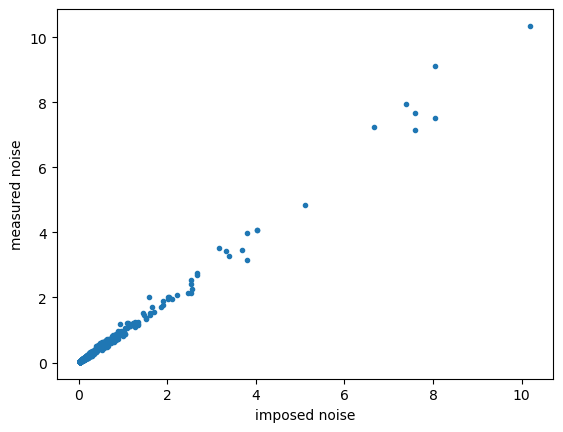

In [97]:
plt.plot(snrs[:,1], snrs[:,2], '.')
plt.xlabel("imposed noise")
plt.ylabel("measured noise")

Text(0, 0.5, 'measured noise')

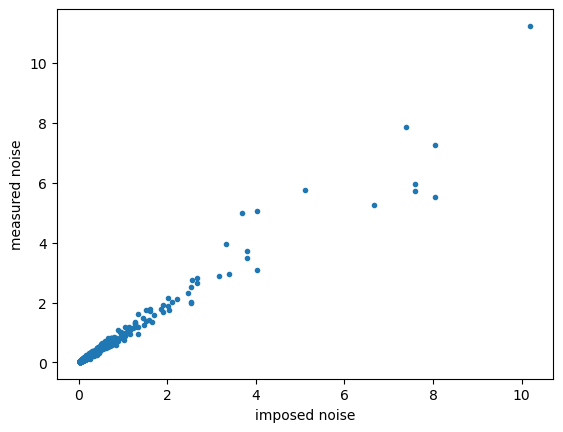

In [90]:
plt.plot(snrs[:,1], snrs[:,2], '.')
plt.xlabel("imposed noise")
plt.ylabel("measured noise")

Text(0, 0.5, 'measured SNR')

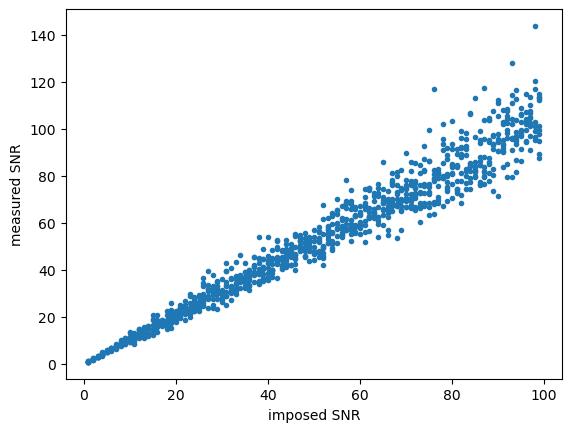

In [95]:
plt.plot(snrs[:,0], snrs[:,3], '.')
plt.xlabel("imposed SNR")
plt.ylabel("measured SNR")

Text(0, 0.5, 'measured SNR')

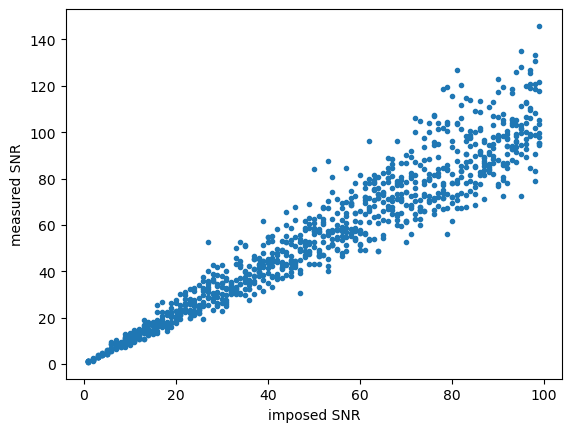

In [91]:
plt.plot(snrs[:,0], snrs[:,3], '.')
plt.xlabel("imposed SNR")
plt.ylabel("measured SNR")

In [31]:
for i in tqdm(range(num_spectra)):
    i_row_series = df_meta.loc[i]
    i_spectra = spectra[i]
    i_spectra_signal = spectra_signal[i]
    i_spectra_noise = spectra_noise[i]
    i_new_noise = new_noise[i]

    # i_specsnr = ms.SpectrumSNR(
    #     i_row_series["SN Name"],
    #     i_row_series["SN Subtype"],
    #     i_row_series["Spectrum Phase"],
    #     wvl,
    #     i_spectra)
    # i_specsnr.execute_algorithm(i_row_series)

    i_specsnr_new_noise = ms.SpectrumSNR(
        i_row_series["SN Name"],
        i_row_series["SN Subtype"],
        i_row_series["Spectrum Phase"],
        wvl,
        i_spectra)
    i_specsnr_new_noise.execute_algorithm(i_row_series, new_noise=i_new_noise)
    
    df_meta.loc[i, "new_measured_SNR"] = i_specsnr_new_noise.SNR
    df_meta.loc[i, "new_measured_N"] = i_specsnr_new_noise.N

  0%|                                                                                       | 0/3574 [00:00<?, ?it/s]


IndexError: invalid index to scalar variable.

In [6]:
df_meta

,SN Name,Spectrum Phase,Spectrum Cardinality,SN Subtype,SN Maintype,SN Subtype ID,SN Maintype ID,SNR,S (SNR),N (SNR),...,searchRed,minima_i,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed,useBlu,useRed,new_measured_SNR,new_measured_N
0,sn1981b,-1.5,1,Ia-norm,Ia,0,0,1871.524905,10.201020,0.005451,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,115.420670,0.088381
1,sn1981b,15.4,1,Ia-norm,Ia,0,0,2098.887305,6.663471,0.003175,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,107.451399,0.062014
2,sn1981b,18.3,1,Ia-norm,Ia,0,0,2239.138885,7.397255,0.003304,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,103.550416,0.071436
3,sn1981b,22.3,1,Ia-norm,Ia,0,0,556.796633,3.159352,0.005674,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,107.371923,0.029424
4,sn1989b,-7.2,1,Ia-norm,Ia,0,0,1568.676779,8.039676,0.005125,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,99.832981,0.080531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3569,sn2006bp,17.2,1,IIP,II,9,3,1909.429755,7.142203,0.003740,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,103.827577,0.068789
3570,sn2006bp,20.1,1,IIP,II,9,3,639.508576,7.011980,0.010965,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,96.165326,0.072916
3571,sn2006bp,25.2,1,IIP,II,9,3,2430.950291,10.546622,0.004338,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,120.515726,0.087512
3572,sn2006bp,34.1,1,IIP,II,9,3,3897.900603,15.915556,0.004083,...,0.0,NaN,0.0,0.0,100.0,100.0,True,True,105.375962,0.151036


In [19]:
fig = px.scatter(
    data_frame=df_meta,
    x="SNR",
    y="new_measured_SNR",
    color="SN Subtype",
    hover_name="SN Name",
    hover_data=["Spectrum Phase", "N (SNR)", "new_measured_N"],
)
plotly.offline.plot(fig, filename=f"SNR_vs_newMeasuredSNR_atSNR{new_SNR}.html");

In [20]:
fig = px.scatter(
    data_frame=df_meta,
    x="S (SNR)",
    y="new_measured_SNR",
    color="SN Subtype",
    hover_name="SN Name",
    hover_data=["Spectrum Phase", "SNR", "N (SNR)", "new_measured_N"],
)
plotly.offline.plot(fig, filename=f"S_vs_newMeasuredSNR_atSNR{new_SNR}.html")

'S_vs_newMeasuredSNR_atSNR100.html'